# **激活函数与权重初始化指南**

## 目录

1. [激活函数概述](#1-激活函数概述)
2. [权重初始化方法概述](#2-权重初始化方法概述)
3. [激活函数与推荐初始化方法](#3-激活函数与推荐初始化方法)
   - [3.1 Sigmoid 函数](#31-sigmoid-函数)
   - [3.2 Tanh 函数](#32-tanh-函数)
   - [3.3 ReLU 及其变种](#33-relu-及其变种)
     - [3.3.1 ReLU](#331-relu)
     - [3.3.2 Leaky ReLU](#332-leaky-relu)
     - [3.3.3 Parametric ReLU (PReLU)](#333-parametric-relu-prelu)
     - [3.3.4 ELU (Exponential Linear Unit)](#334-elu-exponential-linear-unit)
     - [3.3.5 SELU (Scaled ELU)](#335-selu-scaled-elu)
   - [3.4 GELU (Gaussian Error Linear Unit)](#34-gelu-gaussian-error-linear-unit)
   - [3.5 Swish](#35-swish)
4. [推荐初始化方法总结](#4-推荐初始化方法总结)
5. [激活函数与初始化方法总结表](#5-激活函数与初始化方法总结表)
6. [实际应用中的注意事项](#6-实际应用中的注意事项)
7. [结论](#7-结论)

---

## **1. 激活函数概述**

激活函数的主要作用是为神经网络引入非线性，使其能够拟合复杂的函数关系，常用的激活函数有：

- **Sigmoid（S型函数）**
- **Tanh（双曲正切函数）**
- **ReLU（Rectified Linear Unit）及其变种**
- **GELU（Gaussian Error Linear Unit）**
- **Swish**

每种激活函数都有其独特的特性和适用场景。

---

## **2. 权重初始化方法概述**

权重初始化对于神经网络的训练至关重要，合适的初始化可以加速收敛，避免梯度消失或爆炸问题，以下是几种常用的初始化方法：

- **Xavier（Glorot）初始化**
- **He（Kaiming）初始化**
- **LeCun 初始化**
- **Orthogonal 初始化**

每种初始化方法根据激活函数的特性进行设计，以维持前向传播和反向传播中的信号稳定。

---

## **3. 激活函数与推荐初始化方法**





### **3.1 Sigmoid 函数**

#### **定义**
Sigmoid 函数将输入映射到 (0, 1) 之间：$\sigma(x) = \frac{1}{1 + e^{-x}}$


#### **特性**
- **优点**：输出值有明确的概率解释，适用于二分类问题的输出层。
- **缺点**：容易出现梯度消失问题，特别是在深层网络中；输出非零中心化。

#### **推荐初始化方法**
- **Xavier（Glorot）初始化**：适用于 Sigmoid 和 Tanh，因为它考虑了输入和输出的方差，有助于保持信号在前向和反向传播中的稳定性。
$
  \text{Var}(W) = \frac{1}{n_{\text{in}}}
$
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.xavier_uniform_(layer.weight)

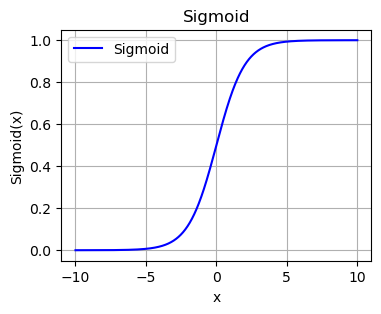

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 1000)
y = sigmoid(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='Sigmoid', color='blue')
plt.title('Sigmoid')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')
plt.grid(True)
plt.legend()
plt.show()

---

### **3.2 Tanh 函数**




#### **定义**
Tanh 函数将输入映射到 (-1, 1) 之间：
$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$

#### **特性**
- **优点**：
  - **输出中心化**：输出值以 0 为中心，有助于加快梯度下降的收敛速度。
  - **非线性**：引入非线性，使神经网络能够拟合复杂的函数关系。

- **缺点**：
  - **梯度消失**：在输入值较大或较小时，梯度接近于零，特别是在深层网络中，可能导致梯度消失问题。
  - **计算复杂度**：相比于 ReLU，Tanh 的计算稍微复杂一些。

#### **推荐初始化方法**
- **Xavier（Glorot）初始化**：适用于 Tanh 函数，因为它考虑了输入和输出的方差，有助于保持信号在前向和反向传播中的稳定性。
  $
  \text{Var}(W) = \frac{1}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.xavier_uniform_(layer.weight)

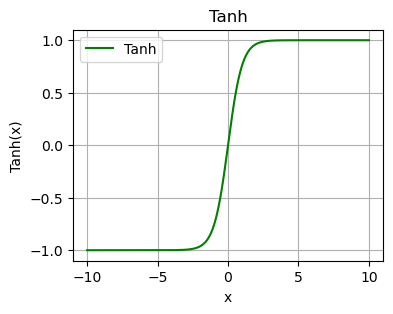

In [8]:
def tanh(x):
    return np.tanh(x)

x = np.linspace(-10, 10, 1000)
y = tanh(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='Tanh', color='green')
plt.title('Tanh')
plt.xlabel('x')
plt.ylabel('Tanh(x)')
plt.grid(True)
plt.legend()
plt.show()

---

### **3.3. ReLU 及其变种**

### **3.3.1 ReLU**

#### **定义**
ReLU（Rectified Linear Unit）函数将输入的负值置零，正值保持不变：
$
\text{ReLU}(x) = \max(0, x)
$

#### **特性**
- **优点**：
  - **计算简单**：ReLU 的计算非常高效，只需比较输入是否大于零。
  - **缓解梯度消失**：在正区间，ReLU 的梯度恒为 1，有助于缓解梯度消失问题，加速收敛。
  - **稀疏激活**：ReLU 会将负值部分置零，导致网络具有稀疏激活特性，有助于减少过拟合。
- **缺点**：
  - **“Dead ReLU”问题**：在训练过程中，如果某些神经元的输入总是负值，它们将永远输出 0，导致这些神经元在整个训练过程中都不起作用。
  - **非零中心**：ReLU 的输出不是以 0 为中心的，这可能导致梯度更新时的不平衡。

#### **推荐初始化方法**
- **He（Kaiming）初始化**：专为 ReLU 设计，考虑了 ReLU 的非对称性，有助于保持前向传播和反向传播中的信号稳定。
  $
  \text{Var}(W) = \frac{2}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')


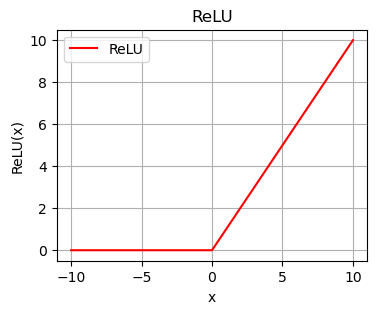

In [11]:
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 1000)
y = relu(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='ReLU', color='red')
plt.title('ReLU')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.grid(True)
plt.legend()
plt.show()


---

#### **3.3.2 Leaky ReLU**

##### **定义**
Leaky ReLU 函数在负值区域引入一个小的线性部分，避免了“Dead ReLU”问题：
$
\text{Leaky ReLU}(x) = 
\begin{cases} 
x & \text{if } x > 0 \\
\alpha x & \text{otherwise}
\end{cases}
$
, 通常，$\alpha = 0.01$。

##### **特性**
- **优点**：
  - **缓解“Dead ReLU”问题**：通过允许负值有一个小的斜率，Leaky ReLU 防止了神经元在训练过程中完全不激活。
  - **梯度流动**：负值区域的梯度不会完全为零，有助于保持梯度流动，促进更稳定的训练。
  - **稀疏激活**：类似于 ReLU，Leaky ReLU 仍然能够实现稀疏激活，减少过拟合。

- **缺点**：
  - **引入超参数**：需要选择合适的 $\alpha$ 值，不同的 $\alpha$ 可能会影响模型性能。
  - **计算复杂度**：相比于 ReLU，Leaky ReLU 增加了一些计算开销，尽管通常可以忽略不计。

##### **推荐初始化方法**
- **He（Kaiming）初始化**：适用于 Leaky ReLU，因为它考虑了激活函数的非对称性，确保信号在前向传播和反向传播中的稳定性。
  $
  \text{Var}(W) = \frac{2}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.kaiming_uniform_(layer.weight, a=0.01, nonlinearity='leaky_relu')


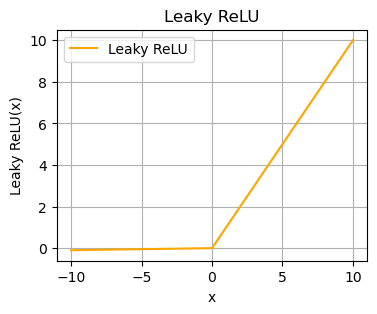

In [12]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

x = np.linspace(-10, 10, 1000)
y = leaky_relu(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='Leaky ReLU', color='orange')
plt.title('Leaky ReLU')
plt.xlabel('x')
plt.ylabel('Leaky ReLU(x)')
plt.grid(True)
plt.legend()
plt.show()


---

#### **3.3.3 Parametric ReLU (PReLU)**




##### **定义**
Parametric ReLU（PReLU）是一种带参数的线性整流单元，它允许负值区域的斜率 $\alpha$ 作为可学习的参数：
$
\text{PReLU}(x) = 
\begin{cases} 
x & \text{if } x > 0 \\
\alpha x & \text{otherwise}
\end{cases}
$
, 通常，$\alpha$ 被初始化为一个小的正值（例如，0.25）。

##### **特性**
- **优点**：
  - **提高模型表达能力**：通过学习 $\alpha$，PReLU 能够自适应地调整负值区域的斜率，从而提升模型的表达能力。
  - **缓解“死亡 ReLU”问题**：与 Leaky ReLU 类似，PReLU 允许负值梯度流动，减少神经元长期不激活的风险。
  - **灵活性**：由于 $\alpha$ 是可学习的参数，PReLU 能够为每个神经元自适应调整，提供更高的灵活性。

- **缺点**：
  - **增加模型参数**：每个 PReLU 激活单元都需要学习一个 $\alpha$ 参数，可能会增加模型的复杂度和计算开销。
  - **过拟合风险**：额外的参数可能会增加模型过拟合的风险，尤其是在训练数据不足的情况下。

##### **推荐初始化方法**
- **He（Kaiming）初始化**：适用于 PReLU，因为它与 Leaky ReLU 类似，考虑了激活函数的非对称性，有助于保持前向传播和反向传播中的信号稳定性。
  $
  \text{Var}(W) = \frac{2}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.kaiming_uniform_(layer.weight, a=0.25, nonlinearity='leaky_relu')

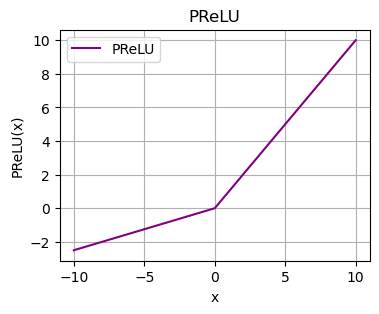

In [13]:
def prelu(x, alpha=0.25):
    return np.where(x > 0, x, alpha * x)

x = np.linspace(-10, 10, 1000)
y = prelu(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='PReLU', color='purple')
plt.title('PReLU')
plt.xlabel('x')
plt.ylabel('PReLU(x)')
plt.grid(True)
plt.legend()
plt.show()

---

#### **3.3.4 ELU (Exponential Linear Unit)**




##### **定义**
ELU（Exponential Linear Unit，指数线性单元）函数在负半轴引入指数函数，使其在负值区域具有平滑的非线性特性：


$
\text{ELU}(x) = 
\begin{cases} 
x & \text{if } x > 0 \\
\alpha (e^{x} - 1) & \text{otherwise}
\end{cases}
$
, 通常，$\alpha = 1$。

##### **特性**
- **优点**：
  - **输出接近零中心**：ELU 在负值区域输出负值，有助于使激活函数的输出更加接近零中心，促进更快的收敛。
  - **缓解梯度消失**：相比于 Sigmoid 和 Tanh，ELU 在正值区域具有恒定的梯度，有助于缓解梯度消失问题。
  - **平滑性**：ELU 的曲线在 $x = 0$ 处是连续且可导的，提供了更平滑的梯度流动。
- **缺点**：
  - **计算复杂度较高**：由于需要计算指数函数，ELU 的计算复杂度略高于 ReLU。
  - **负值可能导致梯度消失**：在负值区域，随着 $x$ 趋近于负无穷，梯度趋近于零，可能导致梯度消失问题。

##### **推荐初始化方法**
- **He（Kaiming）初始化**：适用于 ELU，因为它考虑了激活函数的非对称性，有助于保持前向传播和反向传播中的信号稳定性。
  $
  \text{Var}(W) = \frac{2}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.kaiming_uniform_(layer.weight, nonlinearity='elu')

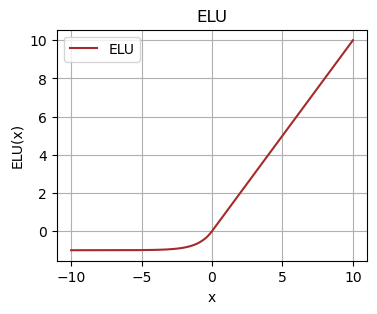

In [22]:
def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

x = np.linspace(-10, 10, 1000)
y = elu(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='ELU', color='brown')
plt.title('ELU')
plt.xlabel('x')
plt.ylabel('ELU(x)')
plt.grid(True)
plt.legend()
plt.show()


---

### **3.3.5 SELU (Scaled ELU)**



#### **定义**
SELU（Scaled Exponential Linear Unit）函数在 ELU 的基础上进行了缩放，使其满足自归一化特性：
$
\text{SELU}(x) = \lambda \begin{cases} 
x & \text{if } x > 0 \\
\alpha (e^{x} - 1) & \text{otherwise}
\end{cases}
$

通常，$\alpha \approx 1.67326$，$\lambda \approx 1.0507$。

#### **特性**
- **优点**：
  - **自动归一化**：SELU 的设计使得神经网络在前向传播过程中能够自动保持激活值的均值和方差，从而促进深层网络的训练。
  - **促进收敛**：自归一化特性有助于加快模型的收敛速度，特别是在深层网络中。
  - **稳定性**：在深层网络中，SELU 能够保持信号的稳定性，减少梯度消失或爆炸的风险。
- **缺点**：
  - **对网络结构敏感**：SELU 依赖于特定的网络结构（如全连接网络），并且通常需要使用特定的初始化和避免使用 Dropout。
  - **对初始化和正则化有严格要求**：使用 SELU 时，必须使用 LeCun 初始化，并且某些正则化方法（如 Dropout）可能会破坏自归一化特性。

#### **推荐初始化方法**
- **LeCun 初始化**：专为 SELU 设计，确保自归一化特性。
  $
  \text{Var}(W) = \frac{1}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  import numpy as np
  
  nn.init.normal_(layer.weight, mean=0, std=1.0 / np.sqrt(layer.in_features))


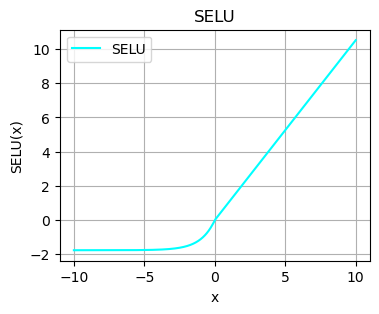

In [26]:
def selu(x, alpha=1.67326, lam=1.0507):
    return lam * np.where(x > 0, x, alpha * (np.exp(x) - 1))

x = np.linspace(-10, 10, 1000)
y = selu(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='SELU', color='cyan')
plt.title('SELU')
plt.xlabel('x')
plt.ylabel('SELU(x)')
plt.grid(True)
plt.legend()
plt.show()


---

### **3.4 GELU (Gaussian Error Linear Unit)**



#### **定义**
GELU（Gaussian Error Linear Unit）函数结合了线性和非线性，基于高斯误差函数：
$
\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2} \left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]
$

或者其近似形式：
$
\text{GELU}(x) \approx 0.5x \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \left(x + 0.044715x^3\right)\right]\right)
$

#### **特性**
- **优点**：
  - **平滑非线性**：GELU 提供了一种平滑且连续的激活方式，相比于 ReLU 的硬阈值，更加柔和。
  - **保留负值信息**：不同于 ReLU 完全将负值置零，GELU 以概率性的方式保留部分负值信息，有助于模型捕捉更多特征。
  - **梯度流动**：由于 GELU 在整个输入范围内都是可微的，梯度能够更顺畅地传递，促进更稳定的训练。
  - **适用于现代架构**：GELU 在 Transformer 等先进模型中表现出色，提升了模型的表达能力和性能。
- **缺点**：
  - **计算复杂度**：相比于 ReLU，GELU 需要计算误差函数 erf 或其近似，这增加了计算开销。
  - **实现复杂性**：由于涉及高阶函数，GELU 的实现比 ReLU 更为复杂，可能影响计算效率。

#### **推荐初始化方法**
- **He（Kaiming）初始化**：适用于 GELU，因为它是一种非线性激活函数，He 初始化有助于保持前向传播和反向传播中的信号稳定性。
  $
  \text{Var}(W) = \frac{2}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')


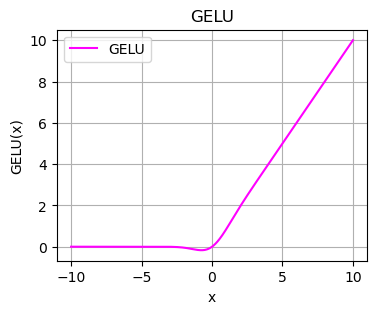

In [23]:
from scipy.special import erf

def gelu(x):
    return 0.5 * x * (1 + erf(x / np.sqrt(2)))

x = np.linspace(-10, 10, 1000)
y = gelu(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='GELU', color='magenta')
plt.title('GELU')
plt.xlabel('x')
plt.ylabel('GELU(x)')
plt.grid(True)
plt.legend()
plt.show()


---

### **3.5 Swish**



#### **定义**
Swish 是一种自门控激活函数，由 Google 提出，旨在结合 ReLU 的优点并克服其一些缺点：
$
\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}
$
其中，$\sigma(x)$ 是 Sigmoid 函数。

#### **特性**
- **优点**：
  - **平滑且非线性**：Swish 的输出在所有输入值上都是连续且可微的，有助于优化过程。
  - **自适应信息流动**：Swish 能够根据输入自适应地调整信息流动，允许部分负值信息通过，这有助于提高模型的表达能力。
  - **缓解“死亡 ReLU”问题**：与 ReLU 不同，Swish 在负值区域不会完全将输出置零，减少了神经元“死亡”的可能性。
  - **性能提升**：在某些任务和模型架构中，Swish 已被证明能够提供比 ReLU 更好的性能表现。
- **缺点**：
  - **计算复杂度较高**：相比于 ReLU，Swish 需要计算 Sigmoid 函数，增加了计算开销。
  - **实现复杂性**：在某些硬件或框架中，Swish 的实现可能不如 ReLU 高效，尤其是在大规模部署时。

#### **推荐初始化方法**
- **He（Kaiming）初始化**：适用于 Swish，因为它类似于 ReLU，He 初始化有助于保持信号在前向传播和反向传播中的稳定性。
  $
  \text{Var}(W) = \frac{2}{n_{\text{in}}}
  $
  
- **具体应用**：
  ```python
  import torch.nn as nn
  nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')


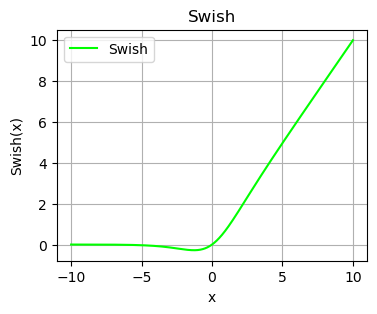

In [25]:
def swish(x):
    return x / (1 + np.exp(-x))

x = np.linspace(-10, 10, 1000)
y = swish(x)

plt.figure(figsize=(4, 3))
plt.plot(x, y, label='Swish', color='lime')
plt.title('Swish')
plt.xlabel('x')
plt.ylabel('Swish(x)')
plt.grid(True)
plt.legend()
plt.show()


---

## **4. 推荐初始化方法总结**

权重初始化在深度学习模型的训练过程中扮演着关键角色，影响着模型的收敛速度和最终性能。以下是针对不同激活函数推荐的初始化方法总结：

- **ReLU 及其变种**：
  - **推荐初始化方法**：He（Kaiming）初始化
  - **原因**：适用于 ReLU 及其变种，能够缓解梯度消失问题，并促进稀疏激活。
- **Sigmoid 和 Tanh**：
  - **推荐初始化方法**：Xavier（Glorot）初始化
  - **原因**：保持前向和反向传播中的信号稳定，适用于 Sigmoid 和 Tanh 等输出非零中心化的激活函数。
- **GELU 和 Swish**：
  - **推荐初始化方法**：He（Kaiming）初始化
  - **原因**：适用于需要复杂激活行为的现代深度学习模型，有助于保持信号稳定性。
- **SELU**：
  - **推荐初始化方法**：LeCun 初始化
  - **原因**：确保自归一化特性，适用于 SELU 激活函数。
- **Softmax**：
  - **推荐初始化方法**：Xavier（Glorot）初始化
  - **原因**：通常用于输出层，保持信号稳定。
- **结合批量归一化**：
  - **说明**：批量归一化常与 ReLU 等激活函数配合使用，进一步提升训练稳定性和收敛速度。

通过合理选择和匹配激活函数与权重初始化方法，可以有效提升神经网络的训练效率和最终性能。


---

## **5. 激活函数与初始化方法总结表**

以下是主要激活函数及其推荐初始化方法的总结表：

| 激活函数            | 数学表达式                                                     | 推荐初始化方法      | 初始化方差公式                 | 备注                                                         |
|---------------------|----------------------------------------------------------------|---------------------|---------------------------------|--------------------------------------------------------------|
| **Sigmoid**         | $ \sigma(x) = \frac{1}{1 + e^{-x}} $                        | Xavier (Glorot)     | $ \frac{1}{n_{\text{in}}} $ | 适用于 Sigmoid 和 Tanh                                      |
| **Tanh**            | $ \tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} $       | Xavier (Glorot)     | $ \frac{1}{n_{\text{in}}} $ |                                                              |
| **ReLU**            | $ \text{ReLU}(x) = \max(0, x) $                             | He (Kaiming)        | $ \frac{2}{n_{\text{in}}} $ | 专为 ReLU 设计                                               |
| **Leaky ReLU**      | $ \text{Leaky ReLU}(x) = \begin{cases} x & x > 0 \\ \alpha x & \text{else} \end{cases} $ | He (Kaiming)        | $ \frac{2}{n_{\text{in}}} $ | 需指定负斜率 $ \alpha $                                    |
| **PReLU**           | $ \text{PReLU}(x) = \begin{cases} x & x > 0 \\ \alpha x & \text{else} \end{cases} $   | He (Kaiming)        | $ \frac{2}{n_{\text{in}}} $ | 学习负斜率参数                                               |
| **ELU**             | $ \text{ELU}(x) = \begin{cases} x & x > 0 \\ \alpha (e^{x} - 1) & \text{else} \end{cases} $ | He (Kaiming)        | $ \frac{2}{n_{\text{in}}} $ |                                                              |
| **SELU**            | $ \text{SELU}(x) = \lambda \cdot \text{ELU}(x) $            | LeCun               | $ \frac{1}{n_{\text{in}}} $ | 需满足自归一化特性                                           |
| **GELU**            | $ \text{GELU}(x) = x \cdot \Phi(x) $                        | He (Kaiming)        | $ \frac{2}{n_{\text{in}}} $ | 类似 ReLU 的激活函数                                        |
| **Swish**           | $ \text{Swish}(x) = x \cdot \sigma(x) $                      | He (Kaiming)        | $ \frac{2}{n_{\text{in}}} $ | 类似 ReLU 的激活函数                                        |
| **Softmax**         | $ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} $    | Xavier (Glorot)     | $ \frac{1}{n_{\text{in}}} $ | 通常用于输出层                                               |


---

## **6. 实际应用中的注意事项**

在实际应用中，选择合适的激活函数和初始化方法不仅依赖于理论上的优势，还需要考虑具体任务、网络结构以及训练过程中的动态表现。

以下是一些在实际应用中需要注意的事项：

### **1. 激活函数的选择**
- **浅层网络**：
  - 对于浅层网络，Sigmoid 和 Tanh 曾经被广泛使用，因为它们的平滑性和可导性。但由于梯度消失问题，现在更多地使用 ReLU 及其变种。
- **深层网络**：
  - 在深层网络中，ReLU 及其变种（如 Leaky ReLU、PReLU、ELU）因其缓解梯度消失问题，促进稀疏激活，成为首选激活函数。
- **特定任务**：
  - 在某些任务（如自然语言处理中的 Transformer）中，GELU 和 Swish 被证明能够提供更好的性能，适用于需要更复杂激活行为的模型。

### **2. 初始化方法的选择**
- **激活函数匹配**：
  - 确保选择的初始化方法与激活函数匹配，以维持信号在前向传播和反向传播中的稳定性。例如，使用 ReLU 时推荐 He 初始化，使用 Sigmoid 或 Tanh 时推荐 Xavier 初始化。
  
- **自定义初始化**：
  - 在某些情况下，可以根据具体需求自定义初始化方法，但需谨慎验证其效果。自定义初始化可能会基于任务特点或实验数据进行调整，以优化模型性能。

### **3. 结合正则化**
- **批量归一化（Batch Normalization）**：
  - 批量归一化常与 ReLU 等激活函数结合使用，进一步稳定训练过程，减少内部协变量偏移，加速收敛。
- **权重正则化**：
  - 如 L2 正则化（权重衰减），可以防止过拟合，尤其在使用复杂激活函数（如 GELU 和 Swish）时尤为重要。正则化方法应根据模型复杂度和数据量进行选择和调整。

### **4. 实验与验证**
- **监控训练过程**：
  - 通过监控损失函数、梯度分布和激活分布，确保初始化和激活函数的选择不会导致训练不稳定。可以使用可视化工具（如 TensorBoard）来实时观察这些指标。
  
- **超参数调优**：
  - 根据具体任务和数据，适当调整初始化参数（如方差）和激活函数参数（如 Leaky ReLU 的 \(\alpha\)）。超参数调优可以通过网格搜索、随机搜索或贝叶斯优化等方法进行，以找到最佳配置。

- **早停（Early Stopping）**：
  - 使用早停策略可以防止模型过拟合。在训练过程中，如果验证集上的性能不再提升，则提前停止训练。

### **5. 硬件和框架的考虑**
- **硬件优化**：
  - 某些激活函数（如 Swish 和 GELU）由于计算复杂度较高，可能在某些硬件上运行效率较低。在部署模型时，需要权衡性能和计算资源。
  
- **框架支持**：
  - 确保所使用的深度学习框架对选定的激活函数和初始化方法有良好的支持。例如，PyTorch 和 TensorFlow 都提供了多种初始化方法和内置的激活函数实现，便于集成和使用。


---

## **7. 结论**

激活函数和权重初始化在深度学习模型不可或缺，选择合适的激活函数及其对应的初始化方法，可以显著提升模型的训练效率和最终性能。

以下是关键要点的总结：

- **ReLU 及其变种**：
  - **推荐初始化方法**：He（Kaiming）初始化。
  - **原因**：适合缓解梯度消失问题，并促进稀疏激活，有助于加速模型的收敛。
- **Sigmoid 和 Tanh**：
  - **推荐初始化方法**：Xavier（Glorot）初始化。
  - **原因**：保持前向和反向传播中的信号稳定，适用于这些激活函数的对称性和饱和性。
- **GELU 和 Swish**：
  - **推荐初始化方法**：He（Kaiming）初始化。
  - **原因**：适用于需要复杂激活行为的现代深度学习模型，帮助保持信号的稳定性。
- **SELU**：
  - **推荐初始化方法**：LeCun 初始化。
  - **原因**：确保自归一化特性，适用于深层网络，促进网络的稳定训练。
- **结合批量归一化**：
  - **推荐实践**：常与 ReLU 等激活函数配合使用。
  - **原因**：进一步提升训练稳定性和收敛速度，通过归一化层稳定激活分布。

### **关键总结**

- **协同作用**：激活函数与权重初始化方法之间的良好配合，能够显著提升神经网络的性能和训练效率。
  
- **初始化的重要性**：针对不同激活函数选择合适的初始化方法，可以有效避免训练初期的梯度消失或爆炸问题，确保信号在网络中的稳定传播。

- **动态调整**：随着训练的进行，权重会不断调整，激活函数的作用会动态变化，进一步提升模型的表达能力和性能。

- **实际应用中的平衡**：尽管某些激活函数在初始化时可能带来挑战，但通过结合适当的初始化方法和正则化技术，这些问题通常可以得到有效缓解，发挥激活函数的优势。

通过合理选择和组合激活函数与初始化方法，可以有效提升神经网络的性能，促进更高效和稳定的训练过程。这不仅有助于加快模型的收敛速度，还能提高模型在复杂任务中的表现能力。


---